<a href="https://colab.research.google.com/drive/1MvWc5Ybki9pXD62DrE3StGCkdUKmPKWy?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 03. PyTorch Computer Vision Exercises [50 points]

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!


In [5]:
# Check for GPU
!nvidia-smi

Thu Mar  5 22:17:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-32GB           On  |   00000000:AF:00.0 Off |                    0 |
| N/A   39C    P0             60W /  300W |     414MiB /   9537MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.9.1+cu128


'cuda'

## 1. [3 points] Propose 3 areas in industry where computer vision is currently being used.

In [7]:
- Autonomous driving
- Defects tracking on production lines
- Medical image analysis

SyntaxError: invalid syntax (3752576793.py, line 1)

## 2. [3 points] Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [ ]:
Overfitting is when a model performs well on the training data but poorly on unseen data. 
This happens when our model try to fit the data too closely, capturing noise and outliers instead of the underlying pattern.

## 3. [3 points] Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [ ]:
1. Regularization
Adds a penalty to large model weights in the loss function.
This discourages overly complex models and forces the model to learn simpler patterns that generalize better.

2. Dropout
Randomly disables a fraction of neurons during training.
This prevents the network from relying too much on specific neurons and encourages it to learn more robust features.

3. Early Stopping
Stops training when validation performance stops improving.
This prevents the model from continuing to fit noise in the training data after it has already learned the useful patterns.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. [5 points] Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [8]:
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Setup train data
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Setup testing data
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
) 

## 6. [3 points] Visualize at least 5 different samples of the MNIST training dataset.

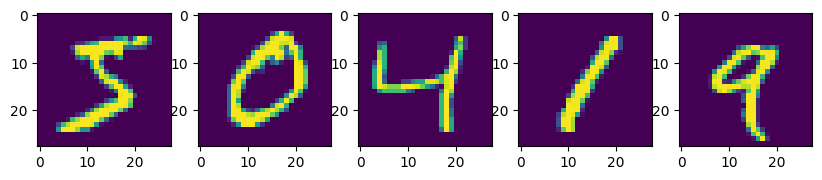

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

for i in range(5):
    image, label = train_data[i]
    plt.subplot(1, 5, i+1)
    plt.imshow(image.squeeze())

plt.show()

## 7. [3 points] Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size= BATCH_SIZE, shuffle= True)
test_dataloader = DataLoader(test_data, batch_size= BATCH_SIZE, shuffle= False)

## 8. [10 points] Recreate `model_2` used in [notebook 03](../tutorials/03_pytorch_computer_vision.ipynb) (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [16]:
class MNISTModel(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size= 3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

torch.manual_seed(42)
model_2 = MNISTModel(input_shape=1,
    hidden_units=10,
    output_shape=len(train_data.classes)).to(device)
model_2

MNISTModel(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. [10 points] Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                             lr=0.1)

from timeit import default_timer as timer
from tqdm.auto import tqdm

def run_training_on(device_to_use):
    torch.manual_seed(42)
    if device_to_use.type == "cuda":
        torch.cuda.manual_seed(42)

    model_2.to(device_to_use)

    train_time_start_model_2 = timer()

    epochs = 5
    for epoch in tqdm(range(epochs)):
        print(f"Epoch: {epoch}\n---------")
        train_step(data_loader=train_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device_to_use
        )

    if device_to_use.type == "cuda":
        torch.cuda.synchronize()
        
    train_time_end_model_2 = timer()
    
    def print_train_time(start: float, end: float, device: torch.device = None):
        total_time = end - start
        print(f"Train time on {device}: {total_time:.3f} seconds")
        return total_time
        
    total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                               end=train_time_end_model_2,
                                               device=device_to_use)
    return total_train_time_model_2

cpu_time = run_training_on(torch.device("cpu"))
gpu_time = run_training_on(torch.device("cuda"))

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.32070 | Train accuracy: 89.19%
Epoch: 1
---------
Train loss: 0.08114 | Train accuracy: 97.45%
Epoch: 2
---------
Train loss: 0.06324 | Train accuracy: 97.99%
Epoch: 3
---------
Train loss: 0.05480 | Train accuracy: 98.31%
Epoch: 4
---------
Train loss: 0.04908 | Train accuracy: 98.48%
Train time on cpu: 115.906 seconds


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.04511 | Train accuracy: 98.57%
Epoch: 1
---------
Train loss: 0.04123 | Train accuracy: 98.70%
Epoch: 2
---------
Train loss: 0.03807 | Train accuracy: 98.83%
Epoch: 3
---------
Train loss: 0.03574 | Train accuracy: 98.87%
Epoch: 4
---------
Train loss: 0.03396 | Train accuracy: 98.95%
Train time on cuda: 53.690 seconds


## 10. [5 points] Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

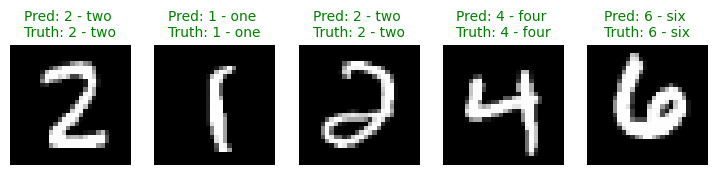

In [14]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob.cpu())

    return torch.stack(pred_probs)

import random
random.seed(42)
class_names = train_data.classes
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k= 5):
    test_samples.append(sample)
    test_labels.append(label)

    

pred_probs= make_predictions(model=model_2, data=test_samples)
pred_classes = pred_probs.argmax(dim=1)

plt.figure(figsize=(9, 9))
nrows = 2
ncols = 5
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")
  pred_label = class_names[pred_classes[i]]
  truth_label = class_names[test_labels[i]]
    
  title_text = f"Pred: {pred_label} \nTruth: {truth_label}"

  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g")
  else:
      plt.title(title_text, fontsize=10, c="r")
  plt.axis(False);

## 11. [5 points] Plot a confusion matrix comparing your model's predictions to the truth labels.


Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

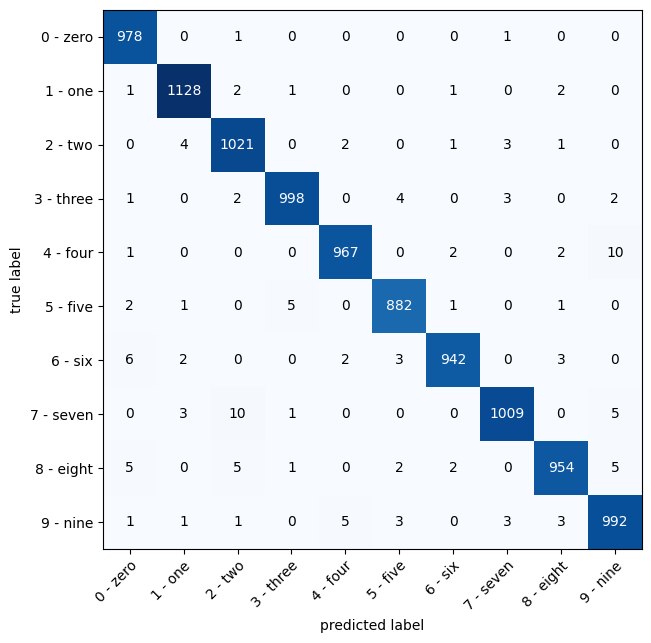

In [15]:
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X, y = X.to(device), y.to(device)
    y_logit = model_2(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
y_pred_tensor = torch.cat(y_preds)

import torchmetrics, mlxtend

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor, target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 7)
);